In [10]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("/content/dataset.csv.csv")
df.head()

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.801,779.445314
1,Afghanistan,1957,9240934,Asia,30.332,820.853030
2,Afghanistan,1962,10267083,Asia,31.997,853.100710
3,Afghanistan,1967,11537966,Asia,34.020,836.197138
4,Afghanistan,1972,13079460,Asia,36.088,739.981106


In [11]:
# Last numeric column as regression target
numeric_cols = df.select_dtypes(include=np.number).columns
target_col = numeric_cols[-1]

# Features and Target
X = df.drop(columns=[target_col])
y_reg = df[target_col]

# Binary classification target
y_clf = (y_reg > y_reg.median()).astype(int)

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Variables created successfully!")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

Variables created successfully!
X_train_scaled: (1363, 148)
X_test_scaled : (341, 148)


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_clf_train)

train_pred = dt.predict(X_train_scaled)
test_pred = dt.predict(X_test_scaled)

print("Training Accuracy:", accuracy_score(y_clf_train, train_pred))
print("Testing Accuracy :", accuracy_score(y_clf_test, test_pred))

Training Accuracy: 1.0
Testing Accuracy : 0.8826979472140762


In [13]:
# ==========================================
# Task 2: Controlled Decision Tree
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Controlled Decision Tree Model
controlled_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

# Train the model
controlled_dt.fit(X_train_scaled, y_clf_train)

# Predictions
train_pred = controlled_dt.predict(X_train_scaled)
test_pred = controlled_dt.predict(X_test_scaled)

# Accuracy
train_accuracy = accuracy_score(y_clf_train, train_pred)
test_accuracy = accuracy_score(y_clf_test, test_pred)

print("===== Controlled Decision Tree =====")
print("Training Accuracy :", round(train_accuracy, 4))
print("Testing Accuracy  :", round(test_accuracy, 4))

# Compare with Baseline Model (Task 1)
print("\nObservation:")
if train_accuracy - test_accuracy < 0.05:
    print("Model is well generalized with less overfitting.")
else:
    print("Model still shows signs of overfitting.")

===== Controlled Decision Tree =====
Training Accuracy : 0.9186
Testing Accuracy  : 0.8739

Observation:
Model is well generalized with less overfitting.


In [14]:
# ==========================================
# Task 3: Gini vs Entropy Comparison
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Decision Tree using Gini
gini_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

gini_model.fit(X_train_scaled, y_clf_train)

gini_pred = gini_model.predict(X_test_scaled)

gini_accuracy = accuracy_score(y_clf_test, gini_pred)


# Decision Tree using Entropy
entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

entropy_model.fit(X_train_scaled, y_clf_train)

entropy_pred = entropy_model.predict(X_test_scaled)

entropy_accuracy = accuracy_score(y_clf_test, entropy_pred)


# Compare Results
comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Test Accuracy": [gini_accuracy, entropy_accuracy]
})

print(comparison)

  Criterion  Test Accuracy
0      Gini       0.873900
1   Entropy       0.868035


Random Forest Test Accuracy: 0.9384

Top 10 Important Features
                  Feature  Importance
2                life_exp    0.395420
146      continent_Europe    0.106285
1              population    0.079393
0                    year    0.055101
144    continent_Americas    0.033107
119  country_South Africa    0.015973
47          country_Gabon    0.014533
63           country_Iraq    0.013472
145        continent_Asia    0.011537
121     country_Sri Lanka    0.009275


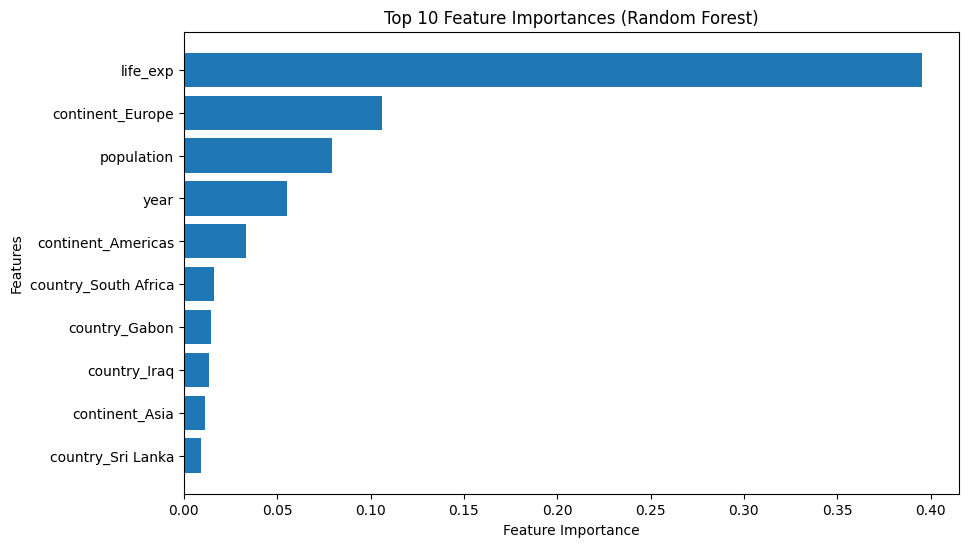

In [15]:
# ==========================================
# Task 4: Random Forest & Feature Importance
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_clf_train)

# Predictions
rf_pred = rf_model.predict(X_test_scaled)

# Accuracy
rf_accuracy = accuracy_score(y_clf_test, rf_pred)

print("Random Forest Test Accuracy:", round(rf_accuracy, 4))

# ------------------------------------------
# Feature Importance
# ------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")
print(feature_importance.head(10))

# ------------------------------------------
# Plot Top 10 Features
# ------------------------------------------

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"].head(10),
    feature_importance["Importance"].head(10)
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()

plt.show()

In [16]:
# ==========================================
# Task 5: Cross Validation Comparison
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Controlled Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

# Cross Validation
for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_clf_train,
        cv=5,
        scoring="roc_auc"
    )

    results.append({
        "Model": name,
        "Mean ROC-AUC": round(scores.mean(), 4),
        "Std Dev": round(scores.std(), 4)
    })

# Display Results
results_df = pd.DataFrame(results)

print(results_df)

                      Model  Mean ROC-AUC  Std Dev
0       Logistic Regression        0.9844   0.0041
1  Controlled Decision Tree        0.9285   0.0174
2             Random Forest        0.9860   0.0024
3         Gradient Boosting        0.9763   0.0063


In [17]:
# ==========================================
# Task 6: Hyperparameter Tuning using GridSearchCV
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Base Model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Train
grid_search.fit(X_train_scaled, y_clf_train)

# Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best Cross Validation Score
print("\nBest ROC-AUC Score:")
print(round(grid_search.best_score_, 4))

# Best Model
best_rf = grid_search.best_estimator_

# Prediction
y_pred = best_rf.predict(X_test_scaled)

# Test Accuracy
accuracy = accuracy_score(y_clf_test, y_pred)

print("\nTest Accuracy:")
print(round(accuracy, 4))

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

Best ROC-AUC Score:
0.986

Test Accuracy:
0.9413


   Training Fraction  Train AUC  Validation AUC
0                0.2        1.0        0.952993
1                0.4        1.0        0.974321
2                0.6        1.0        0.985793
3                0.8        1.0        0.987564
4                1.0        1.0        0.989474


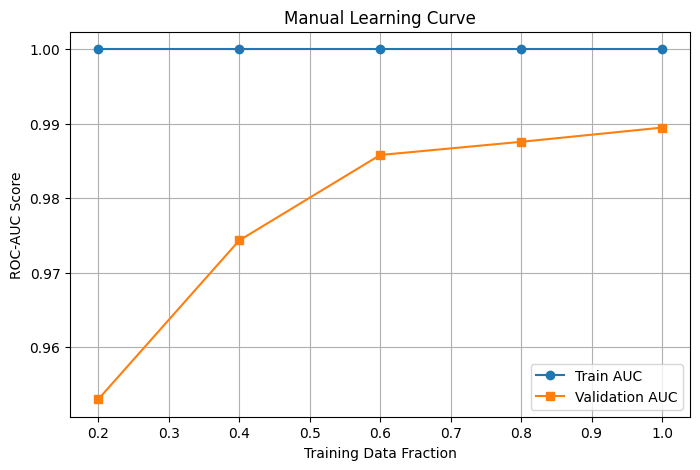

In [18]:
# ==========================================
# Task 7: Manual Learning Curve
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Training data fractions
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

train_auc = []
test_auc = []

for frac in fractions:

    # Number of samples
    n_samples = int(len(X_train_scaled) * frac)

    # Subset of training data
    X_subset = X_train_scaled[:n_samples]
    y_subset = y_clf_train.iloc[:n_samples]

    # Train Random Forest
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_subset, y_subset)

    # Train AUC
    train_prob = model.predict_proba(X_subset)[:, 1]
    train_score = roc_auc_score(y_subset, train_prob)

    # Validation AUC
    test_prob = model.predict_proba(X_test_scaled)[:, 1]
    test_score = roc_auc_score(y_clf_test, test_prob)

    train_auc.append(train_score)
    test_auc.append(test_score)

# Results Table
results = pd.DataFrame({
    "Training Fraction": fractions,
    "Train AUC": train_auc,
    "Validation AUC": test_auc
})

print(results)

# Plot Learning Curve
plt.figure(figsize=(8,5))

plt.plot(fractions, train_auc, marker='o', label='Train AUC')
plt.plot(fractions, test_auc, marker='s', label='Validation AUC')

plt.xlabel("Training Data Fraction")
plt.ylabel("ROC-AUC Score")
plt.title("Manual Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
# ==========================================
# Task 8: Model Serialization
# ==========================================

import joblib
from sklearn.metrics import accuracy_score

# Save the Best Random Forest Model
joblib.dump(best_rf, "best_random_forest_model.pkl")

print("Model saved successfully!")

# Load the Saved Model
loaded_model = joblib.load("best_random_forest_model.pkl")

print("Model loaded successfully!")

# Make Predictions
loaded_predictions = loaded_model.predict(X_test_scaled)

# Check Accuracy
accuracy = accuracy_score(y_clf_test, loaded_predictions)

print("Accuracy of Loaded Model:", round(accuracy, 4))

Model saved successfully!
Model loaded successfully!
Accuracy of Loaded Model: 0.9413


In [20]:
# ==========================================
# Task 9: Final Model Comparison
# ==========================================

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

# Predictions
dt_pred = controlled_dt.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_scaled)
gb_pred = models["Gradient Boosting"].fit(X_train_scaled, y_clf_train).predict(X_test_scaled)

# Prediction Probabilities
dt_prob = controlled_dt.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
gb_prob = models["Gradient Boosting"].predict_proba(X_test_scaled)[:, 1]

# Comparison Table
comparison = pd.DataFrame({
    "Model": [
        "Controlled Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        round(accuracy_score(y_clf_test, dt_pred), 4),
        round(accuracy_score(y_clf_test, rf_pred), 4),
        round(accuracy_score(y_clf_test, gb_pred), 4)
    ],
    "ROC-AUC": [
        round(roc_auc_score(y_clf_test, dt_prob), 4),
        round(roc_auc_score(y_clf_test, rf_prob), 4),
        round(roc_auc_score(y_clf_test, gb_prob), 4)
    ]
})

print("===== Final Model Comparison =====")
print(comparison)

# Best Model
best_model = comparison.loc[comparison["ROC-AUC"].idxmax()]

print("\n===== Best Model =====")
print(best_model)

===== Final Model Comparison =====
                      Model  Accuracy  ROC-AUC
0  Controlled Decision Tree    0.8739   0.9101
1             Random Forest    0.9384   0.9895
2         Gradient Boosting    0.9296   0.9731

===== Best Model =====
Model       Random Forest
Accuracy           0.9384
ROC-AUC            0.9895
Name: 1, dtype: object
